
# Общая сопоставимая модель с пересекающимися макрофакторами

Этот ноутбук строит единую базовую спецификацию для пяти рынков:

- **США** — S&P 500  
- **Великобритания** — FTSE 100  
- **Япония** — Nikkei 225  
- **Гонконг/Китай** — Hang Seng  
- **Индия** — NIFTY 50  

Цель ноутбука — подготовить общий набор пересекающихся макрофакторов, оценить сопоставимые модели по странам и сохранить таблицы и графики для дальнейшего использования в ВКР.

## Что именно делается

1. Загружаются дневные котировки индексов и переводятся в **квартальную** частоту.  
2. Рассчитываются **квартальные логарифмические доходности** индексов в процентах.  
3. Для каждой страны формируется общий набор факторов:
   - лаг доходности индекса;
   - спред долгосрочной и краткосрочной доходности государственных облигаций (**10Y − 2Y**);
   - инфляция;
   - промышленный / деловой индикатор;
   - рост ВВП;
   - торговый баланс в процентах к номинальному ВВП.
4. Оцениваются **OLS-модели с HAC (Newey–West) стандартными ошибками**.
5. Отдельно считаются **стандартизированные коэффициенты**, чтобы было проще сравнивать относительную силу факторов между странами.
6. Строятся таблицы и графики без автоматических выводов по гипотезам.

## Спецификация модели

Для каждой страны оценивается модель вида:

\[
r_t = lpha + 
ho r_{t-1} + eta_1 Spread_{t-1} + eta_2 Inflation_{t-1} + eta_3 Industrial_{t-1} + eta_4 GDP_{t-1} + eta_5 TradeBalance/GDP_{t-1} + 
arepsilon_t
\]

где \(r_t\) — квартальная логарифмическая доходность фондового индекса.




In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from IPython.display import display
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11


## 1. Пути к данным и базовые словари

In [ ]:
PROJECT_ROOT = Path(".").resolve()
DATA_DIR = PROJECT_ROOT / "data"

INDEX_PATH = DATA_DIR / "data.xlsx"
US_MACRO_PATH = DATA_DIR / "datamfs.xlsx"
OTHER_MACRO_PATH = DATA_DIR / "Macro econ inputs.xlsx"

OUTPUT_DIR = PROJECT_ROOT / "common_macro_model_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COUNTRY_ORDER = ["US", "UK", "Japan", "China", "India"]

INDEX_MAP = {
    "US": "SPX Index",
    "UK": "UKX Index",
    "Japan": "NKY Index",
    "China": "HSI Index",
    "India": "NIFTY Index",
}

COUNTRY_LABELS = {
    "US": "США (S&P 500)",
    "UK": "Великобритания (FTSE 100)",
    "Japan": "Япония (Nikkei 225)",
    "China": "Гонконг/Китай (Hang Seng)",
    "India": "Индия (NIFTY 50)",
}

FACTOR_LABELS = {
    "ret_lag1": "Лаг доходности индекса",
    "term_spread_lag1": "Спред 10Y-2Y",
    "inflation_lag1": "Инфляция",
    "industrial_proxy_lag1": "Промышленность/деловой цикл",
    "industrial_growth_lag1": "Промышленность/деловой цикл",
    "gdp_growth_lag1": "Рост ВВП",
    "trade_balance_pct_gdp_lag1": "Торг. баланс, % ВВП",
}

for p in [INDEX_PATH, US_MACRO_PATH, OTHER_MACRO_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Не найден файл: {p}")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("INDEX_PATH:", INDEX_PATH)
print("US_MACRO_PATH:", US_MACRO_PATH)
print("OTHER_MACRO_PATH:", OTHER_MACRO_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_ROOT: C:\Users\ggwpn\OneDrive\Desktop\Diplom
INDEX_PATH: C:\Users\ggwpn\OneDrive\Desktop\Diplom\data\data.xlsx
US_MACRO_PATH: C:\Users\ggwpn\OneDrive\Desktop\Diplom\data\datamfs.xlsx
OTHER_MACRO_PATH: C:\Users\ggwpn\OneDrive\Desktop\Diplom\data\Macro econ inputs.xlsx
OUTPUT_DIR: C:\Users\ggwpn\OneDrive\Desktop\Diplom\common_macro_model_outputs



## 2. Функции загрузки и подготовки данных


In [ ]:
def load_index_returns():
    indices = pd.read_excel(INDEX_PATH, sheet_name="static")
    indices = indices[["Dates", *INDEX_MAP.values()]].copy()
    indices["Dates"] = pd.to_datetime(indices["Dates"])
    indices = indices.set_index("Dates").sort_index()

    q_prices = indices.resample("QE").last()
    q_returns = 100 * np.log(q_prices).diff()

    q_prices = q_prices.rename(columns={v: k for k, v in INDEX_MAP.items()})
    q_returns = q_returns.rename(columns={v: k for k, v in INDEX_MAP.items()})
    return q_prices, q_returns


def prepare_country_macro(country):
    if country == "US":
        raw = pd.read_excel(US_MACRO_PATH, sheet_name="US")
        raw["Dates"] = pd.to_datetime(raw["Dates"])
        raw = raw.set_index("Dates").sort_index()

        out = pd.DataFrame(index=raw.index)
        out["term_spread"] = raw["GT10 Govt"] - raw["GT2 Govt"]
        out["inflation"] = raw["CPI YOY  Index"]
        out["industrial_proxy"] = 100 * np.log(raw["IP Index"]).diff()
        out["gdp_growth"] = raw["GDP CQOQ Index"]
        out["trade_balance_pct_gdp"] = 100 * raw["USTBTOT  Index"] / raw["GDPUNSA  Index"]

    elif country == "UK":
        raw = pd.read_excel(OTHER_MACRO_PATH, sheet_name="UK")
        raw["Dates"] = pd.to_datetime(raw["Dates"])
        raw = raw.set_index("Dates").sort_index()

        out = pd.DataFrame(index=raw.index)
        out["term_spread"] = raw["GTGBP10Y Govt"] - raw["GTGBP2Y Govt"]
        out["inflation"] = raw["UKRPCJYR Index"]
        out["industrial_proxy"] = raw["UKIPIMOM Index"]
        out["gdp_growth"] = raw["UKGRABIQ Index"]
        out["trade_balance_pct_gdp"] = 100 * raw["UKTBALEE Index"] / raw["ECOXUKS Index"]

    elif country == "Japan":
        raw = pd.read_excel(OTHER_MACRO_PATH, sheet_name="Japan")
        raw["Dates"] = pd.to_datetime(raw["Dates"])
        raw = raw.set_index("Dates").sort_index()

        out = pd.DataFrame(index=raw.index)
        out["term_spread"] = raw["GTJPY10Y Govt"] - raw["GTJPY2Y Govt"]
        out["inflation"] = raw["JNCPIYOY Index"]
        out["industrial_proxy"] = raw["JNIPYOY Index"]
        out["gdp_growth"] = raw["JGDPAGDP Index"]
        out["trade_balance_pct_gdp"] = 100 * raw["ECOYBJPN Index"] / raw["ECOXJPS Index"]

    elif country == "China":
        raw = pd.read_excel(OTHER_MACRO_PATH, sheet_name="China")
        raw["Dates"] = pd.to_datetime(raw["Dates"])
        raw = raw.set_index("Dates").sort_index()

        out = pd.DataFrame(index=raw.index)
        out["term_spread"] = raw["GTCNY10Y Govt"] - raw["GTCNY2Y Govt"]
        out["inflation"] = raw["CNCPIYOY Index"]
        out["industrial_proxy"] = raw["CHVAIOY Index"]
        out["gdp_growth"] = raw["CNGDPC$Y Index"]
        out["trade_balance_pct_gdp"] = 100 * raw["CNFRBAL$ Index"] / raw["ECOXCNN Index"]

    elif country == "India":
        raw = pd.read_excel(OTHER_MACRO_PATH, sheet_name="India")
        raw["Dates"] = pd.to_datetime(raw["Dates"])
        raw = raw.set_index("Dates").sort_index()

        out = pd.DataFrame(index=raw.index)
        out["term_spread"] = raw["GTINR10Y Govt"] - raw["GTINR2Y Govt"]
        out["inflation"] = raw["INFUTOTY Index"]
        out["industrial_proxy"] = raw["INPIINDY Index"]
        out["gdp_growth"] = raw["IGQREGDY Index"]
        out["trade_balance_pct_gdp"] = 100 * raw["ECOYBINN Index"] / raw["ECOXINN Index"]

    else:
        raise ValueError(f"Неизвестная страна: {country}")

    return out.resample("QE").last()


def build_country_dataset(country, q_returns):
    macro_q = prepare_country_macro(country)
    merged = pd.concat([q_returns[country].rename("ret"), macro_q], axis=1).sort_index()

    for col in [
        "ret",
        "term_spread",
        "inflation",
        "industrial_proxy",
        "gdp_growth",
        "trade_balance_pct_gdp",
    ]:
        merged[f"{col}_lag1"] = merged[col].shift(1)

    model_cols = [
        "ret",
        "ret_lag1",
        "term_spread_lag1",
        "inflation_lag1",
        "industrial_proxy_lag1",
        "gdp_growth_lag1",
        "trade_balance_pct_gdp_lag1",
    ]
    return merged[model_cols].dropna()


def fit_country_model(df):
    y = df["ret"]
    X = sm.add_constant(df.drop(columns=["ret"]))
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

    df_std = (df - df.mean()) / df.std(ddof=0)
    y_std = df_std["ret"]
    X_std = sm.add_constant(df_std.drop(columns=["ret"]))
    model_std = sm.OLS(y_std, X_std).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

    return model, model_std


## 3. Квартальные доходности индексов


In [ ]:
q_prices, q_returns = load_index_returns()

display(q_prices.tail())
display(q_returns.describe().T)

,US,UK,Japan,China,India
Dates,,,,,
2024-03-31,5254.35,7952.62,40369.44,16541.42,22326.90
2024-06-30,5460.48,8164.12,39583.08,17718.61,24010.60
2024-09-30,5762.48,8236.95,37919.55,21133.68,25810.85
2024-12-31,5881.63,8173.02,39894.54,20059.95,23644.80
2025-03-31,6086.37,8559.56,39958.87,19700.56,23205.35


,count,mean,std,min,25%,50%,75%,max
US,160.0,2.198244,8.149139,-26.431128,-0.622762,3.628987,6.867991,18.952101
UK,160.0,1.189085,7.851584,-32.312969,-1.821752,2.076131,5.480604,18.913252
Japan,160.0,0.722301,11.042657,-42.013024,-5.498113,2.482697,7.829714,21.018213
China,160.0,1.660679,12.960332,-53.800009,-4.960655,2.936337,8.983462,43.743506
India,138.0,2.873913,14.072386,-38.809222,-3.941955,2.981856,9.933055,81.468831


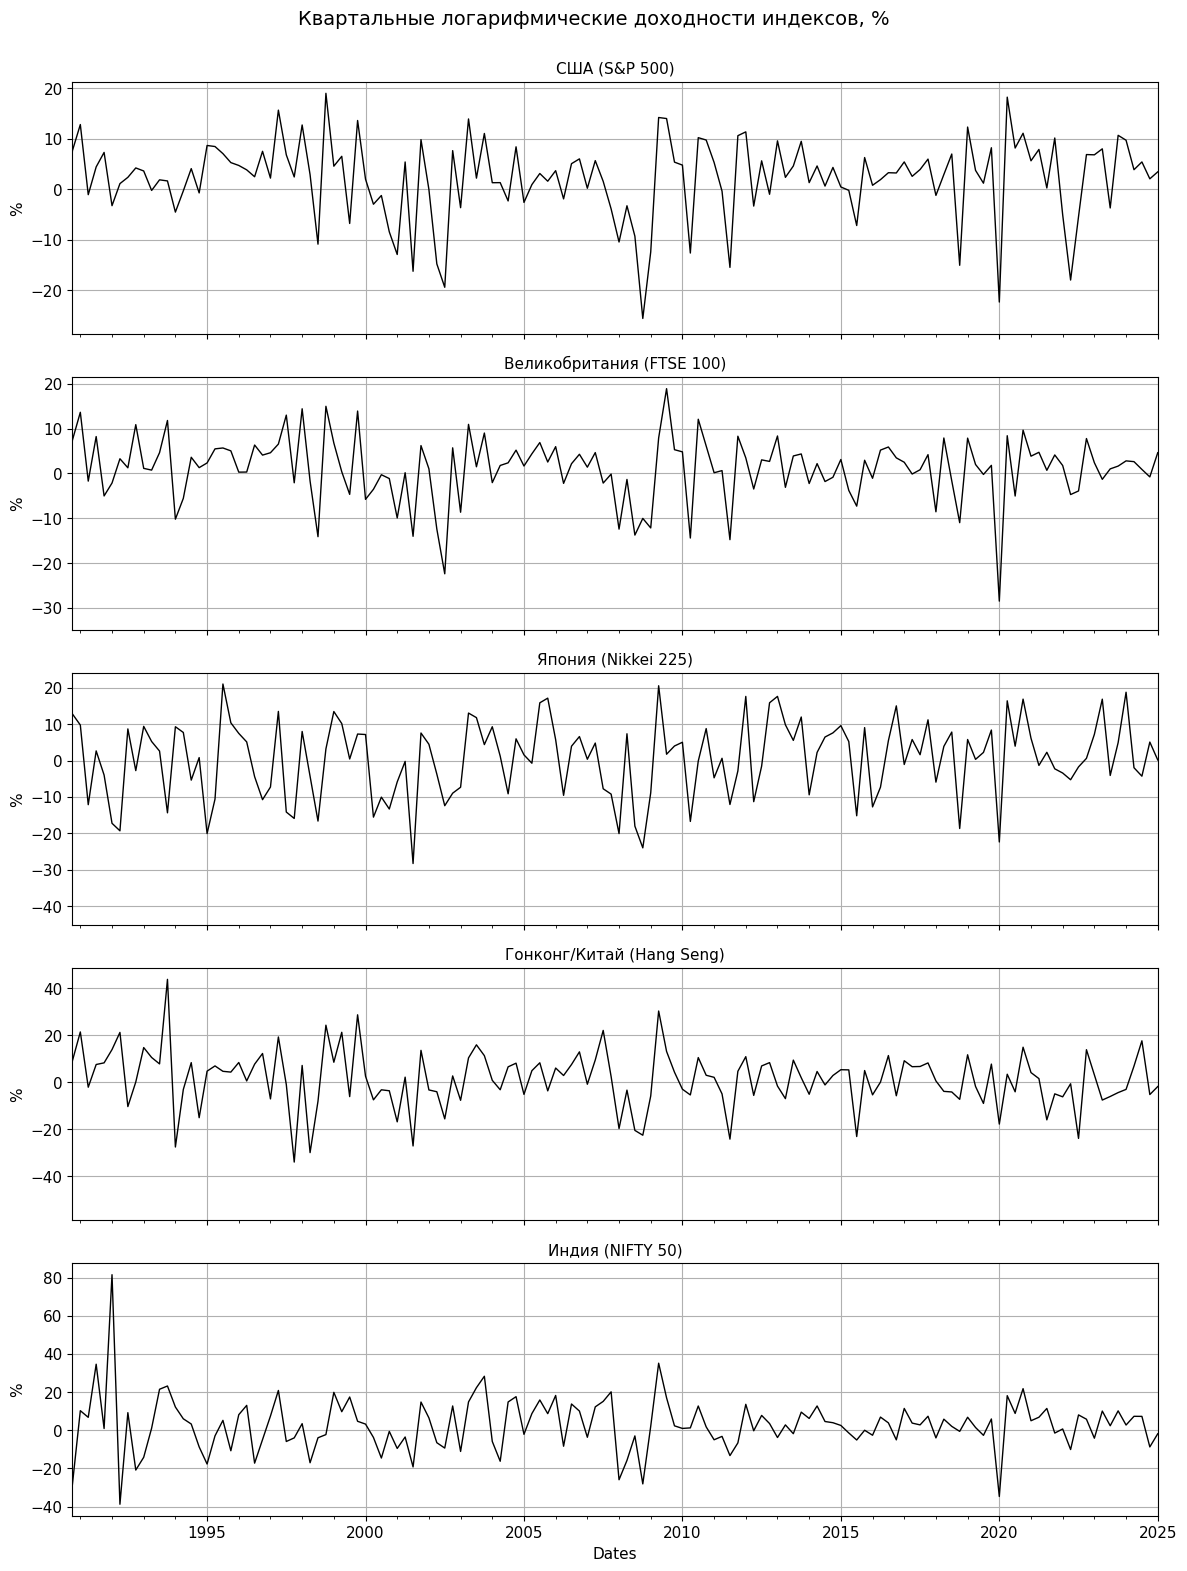

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(12, 16), sharex=True)

for ax, country in zip(axes, COUNTRY_ORDER):
    q_returns[country].dropna().plot(ax=ax, color="black", linewidth=1.0)
    ax.set_title(COUNTRY_LABELS[country], fontsize=11)
    ax.set_ylabel("%")

fig.suptitle("Квартальные логарифмические доходности индексов, %", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig(OUTPUT_DIR / "quarterly_returns.png", dpi=200, bbox_inches="tight")
plt.show()


## 4. Построение общих датасетов по странам
В каждом датасете используется одна и та же спецификация факторов.  
Разница только в доступной длине ряда после объединения и лагирования.


In [ ]:
datasets = {country: build_country_dataset(country, q_returns) for country in COUNTRY_ORDER}

sample_summary = pd.DataFrame(
    [
        {
            "country": country,
            "country_label": COUNTRY_LABELS[country],
            "start_date": df.index.min().date(),
            "end_date": df.index.max().date(),
            "n_obs": len(df),
        }
        for country, df in datasets.items()
    ]
)

display(sample_summary)

,country,country_label,start_date,end_date,n_obs
0,US,США (S&P 500),1992-06-30,2025-03-31,132
1,UK,Великобритания (FTSE 100),1992-06-30,2025-03-31,132
2,Japan,Япония (Nikkei 225),1994-09-30,2025-03-31,123
3,China,Гонконг/Китай (Hang Seng),2006-03-31,2025-03-31,71
4,India,Индия (NIFTY 50),2013-03-31,2025-03-31,49


In [ ]:
returns_adf = []

for country in COUNTRY_ORDER:
    series = q_returns[country].dropna()
    adf_stat, p_value, used_lags, n_obs, *_ = adfuller(series)
    returns_adf.append(
        {
            "country": country,
            "country_label": COUNTRY_LABELS[country],
            "adf_stat": adf_stat,
            "p_value": p_value,
            "lags": used_lags,
            "n_obs": n_obs,
        }
    )

returns_adf = pd.DataFrame(returns_adf)
display(returns_adf)

,country,country_label,adf_stat,p_value,lags,n_obs
0,US,США (S&P 500),-12.496867,2.863341e-23,0,159
1,UK,Великобритания (FTSE 100),-12.982455,2.924422e-24,0,159
2,Japan,Япония (Nikkei 225),-12.350256,5.847161e-23,0,159
3,China,Гонконг/Китай (Hang Seng),-6.872153,1.506062e-09,3,156
4,India,Индия (NIFTY 50),-12.507808,2.716003e-23,0,137



## 5. Описательная статистика и корреляции


In [ ]:
desc_rows = []

for country, df in datasets.items():
    stats = df[
        [
            "ret",
            "ret_lag1",
            "term_spread_lag1",
            "inflation_lag1",
            "industrial_proxy_lag1",
            "gdp_growth_lag1",
            "trade_balance_pct_gdp_lag1",
        ]
    ].describe().T
    stats["country"] = country
    stats["country_label"] = COUNTRY_LABELS[country]
    stats["variable"] = stats.index
    desc_rows.append(stats.reset_index(drop=True))

descriptive_stats = pd.concat(desc_rows, ignore_index=True)
display(descriptive_stats.head(20))

,count,mean,std,min,25%,50%,75%,max,country,country_label,variable
0,132.0,2.055424,7.961050,-25.564370,-0.479641,3.149984,6.803742,18.952101,US,США (S&P 500),ret
1,132.0,2.004763,7.973556,-25.564370,-0.808969,2.994996,6.803742,18.952101,US,США (S&P 500),ret_lag1
2,132.0,1.009992,0.936257,-1.060000,0.237750,0.904000,1.834000,2.808000,US,США (S&P 500),term_spread_lag1
3,132.0,2.584091,1.601423,-1.400000,1.700000,2.500000,3.125000,9.100000,US,США (S&P 500),inflation_lag1
4,132.0,0.082000,0.960846,-4.484921,-0.039096,0.000000,0.337735,6.377139,US,США (S&P 500),industrial_proxy_lag1
5,132.0,2.657576,4.567461,-28.100000,1.475000,2.700000,4.000000,35.200000,US,США (S&P 500),gdp_growth_lag1
6,132.0,-1.020838,0.424059,-1.972754,-1.249323,-0.987231,-0.807503,-0.169872,US,США (S&P 500),trade_balance_pct_gdp_lag1
7,132.0,0.950765,7.204200,-28.501100,-1.724660,1.783764,4.866333,18.913252,UK,Великобритания (FTSE 100),ret
8,132.0,0.899478,7.201969,-28.501100,-1.874902,1.766063,4.866333,18.913252,UK,Великобритания (FTSE 100),ret_lag1
9,132.0,0.654392,0.919899,-1.157900,0.010300,0.530850,1.292950,2.781400,UK,Великобритания (FTSE 100),term_spread_lag1


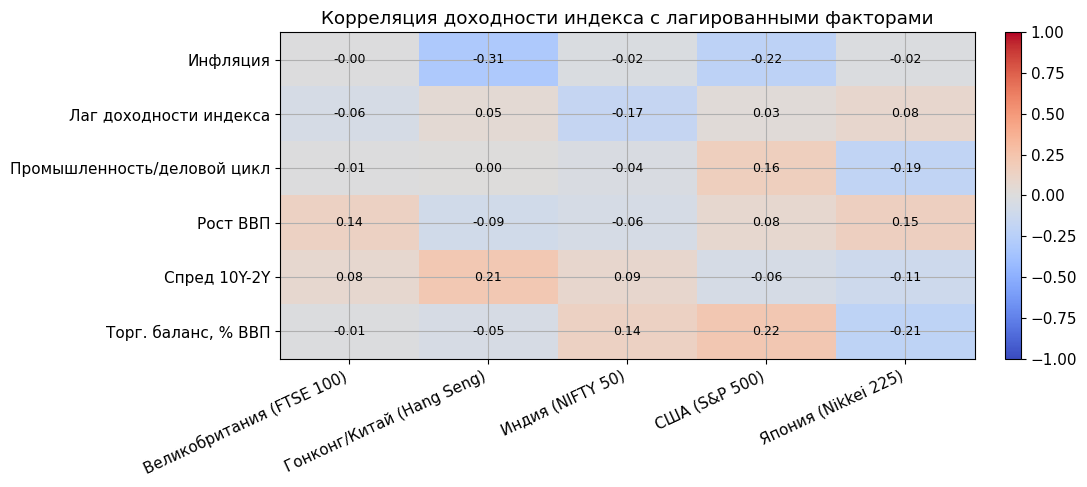

In [ ]:
corr_rows = []

for country in COUNTRY_ORDER:
    df = datasets[country]
    for var in [
        "ret_lag1",
        "term_spread_lag1",
        "inflation_lag1",
        "industrial_proxy_lag1",
        "gdp_growth_lag1",
        "trade_balance_pct_gdp_lag1",
    ]:
        corr_rows.append(
            {
                "country": country,
                "country_label": COUNTRY_LABELS[country],
                "variable": var,
                "variable_label": FACTOR_LABELS[var],
                "corr_with_return": df["ret"].corr(df[var]),
            }
        )

lagged_correlations = pd.DataFrame(corr_rows)

corr_pivot = lagged_correlations.pivot(
    index="variable_label", columns="country_label", values="corr_with_return"
)

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(corr_pivot.values, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_pivot.columns)))
ax.set_xticklabels(corr_pivot.columns, rotation=25, ha="right")
ax.set_yticks(range(len(corr_pivot.index)))
ax.set_yticklabels(corr_pivot.index)

for i in range(corr_pivot.shape[0]):
    for j in range(corr_pivot.shape[1]):
        ax.text(j, i, f"{corr_pivot.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
ax.set_title("Корреляция доходности индекса с лагированными факторами")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "lagged_correlations_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()


## 6. Оценка общей модели по странам
Модели оцениваются методом OLS с **HAC (Newey–West) стандартными ошибками**.  
Дополнительно строится версия со **стандартизированными коэффициентами** для сопоставления относительной силы факторов.


In [ ]:
models = {country: fit_country_model(df) for country, df in datasets.items()}

coef_rows = []
std_coef_rows = []
diagnostic_rows = []
vif_rows = []
fitted_frames = []

for country in COUNTRY_ORDER:
    df = datasets[country]
    model, model_std = models[country]

    for var in model.params.index:
        coef_rows.append(
            {
                "country": country,
                "country_label": COUNTRY_LABELS[country],
                "variable": var,
                "variable_label": FACTOR_LABELS.get(var, "Константа"),
                "coef": model.params[var],
                "std_err": model.bse[var],
                "t_stat": model.tvalues[var],
                "p_value": model.pvalues[var],
            }
        )

    for var in model_std.params.index:
        std_coef_rows.append(
            {
                "country": country,
                "country_label": COUNTRY_LABELS[country],
                "variable": var,
                "variable_label": FACTOR_LABELS.get(var, "Константа"),
                "coef": model_std.params[var],
                "std_err": model_std.bse[var],
                "t_stat": model_std.tvalues[var],
                "p_value": model_std.pvalues[var],
            }
        )

    bg_lm_stat, bg_lm_pvalue, bg_f_stat, bg_f_pvalue = acorr_breusch_godfrey(model, nlags=4)

    diagnostic_rows.append(
        {
            "country": country,
            "country_label": COUNTRY_LABELS[country],
            "n_obs": int(model.nobs),
            "r2": model.rsquared,
            "adj_r2": model.rsquared_adj,
            "durbin_watson": sm.stats.stattools.durbin_watson(model.resid),
            "bg_lm_stat": bg_lm_stat,
            "bg_lm_pvalue": bg_lm_pvalue,
            "bg_f_stat": bg_f_stat,
            "bg_f_pvalue": bg_f_pvalue,
        }
    )

    X_no_const = df.drop(columns=["ret"])
    for i, col in enumerate(X_no_const.columns):
        vif_rows.append(
            {
                "country": country,
                "country_label": COUNTRY_LABELS[country],
                "variable": col,
                "variable_label": FACTOR_LABELS[col],
                "vif": variance_inflation_factor(X_no_const.values, i),
            }
        )

    fitted = pd.DataFrame(
        {
            "country": country,
            "country_label": COUNTRY_LABELS[country],
            "actual_ret": df["ret"],
            "fitted_ret": model.fittedvalues,
            "residuals": model.resid,
        },
        index=df.index,
    )
    fitted_frames.append(fitted)

coef_table = pd.DataFrame(coef_rows)
std_coef_table = pd.DataFrame(std_coef_rows)
diagnostics_table = pd.DataFrame(diagnostic_rows)
vif_table = pd.DataFrame(vif_rows)
fitted_table = pd.concat(fitted_frames).reset_index().rename(columns={"index": "Dates"})

In [ ]:
display(diagnostics_table)

,country,country_label,n_obs,r2,adj_r2,durbin_watson,bg_lm_stat,bg_lm_pvalue,bg_f_stat,bg_f_pvalue
0,US,США (S&P 500),132,0.134568,0.093027,1.965387,0.581271,0.965122,0.133797,0.969656
1,UK,Великобритания (FTSE 100),132,0.036555,-0.009690,1.990005,0.261635,0.992154,0.060077,0.993242
2,Japan,Япония (Nikkei 225),123,0.141559,0.097157,1.951182,4.923266,0.295262,1.167473,0.329049
3,China,Гонконг/Китай (Hang Seng),71,0.196604,0.121286,1.976338,8.925454,0.062990,2.156791,0.084780
4,India,Индия (NIFTY 50),49,0.074220,-0.058035,2.007202,5.259077,0.261732,1.142208,0.351487


In [ ]:
raw_results_view = coef_table.copy()
raw_results_view = raw_results_view.sort_values(["country", "variable"])
display(raw_results_view)

,country,country_label,variable,variable_label,coef,std_err,t_stat,p_value
21,China,Гонконг/Китай (Hang Seng),const,Константа,3.378499,3.889466,0.868628,0.385051
26,China,Гонконг/Китай (Hang Seng),gdp_growth_lag1,Рост ВВП,-1.111360,0.377839,-2.941357,0.003268
25,China,Гонконг/Китай (Hang Seng),industrial_proxy_lag1,Промышленность/деловой цикл,1.516074,0.587222,2.581771,0.009829
24,China,Гонконг/Китай (Hang Seng),inflation_lag1,Инфляция,-3.164122,0.926939,-3.413518,0.000641
22,China,Гонконг/Китай (Hang Seng),ret_lag1,Лаг доходности индекса,-0.139996,0.105102,-1.332004,0.182859
23,China,Гонконг/Китай (Hang Seng),term_spread_lag1,Спред 10Y-2Y,-1.802420,3.627360,-0.496896,0.619263
27,China,Гонконг/Китай (Hang Seng),trade_balance_pct_gdp_lag1,"Торг. баланс, % ВВП",-0.539962,6.608334,-0.081709,0.934878
28,India,Индия (NIFTY 50),const,Константа,9.621598,4.890199,1.967527,0.049122
33,India,Индия (NIFTY 50),gdp_growth_lag1,Рост ВВП,-0.206907,0.206220,-1.003327,0.315703
32,India,Индия (NIFTY 50),industrial_proxy_lag1,Промышленность/деловой цикл,0.130286,0.131777,0.988687,0.322816


In [ ]:
std_results_view = std_coef_table.copy()
std_results_view = std_results_view.sort_values(["country", "variable"])
display(std_results_view)

,country,country_label,variable,variable_label,coef,std_err,t_stat,p_value
21,China,Гонконг/Китай (Hang Seng),const,Константа,3.989864e-17,0.082927,4.811312e-16,1.000000
26,China,Гонконг/Китай (Hang Seng),gdp_growth_lag1,Рост ВВП,-3.988897e-01,0.135614,-2.941357e+00,0.003268
25,China,Гонконг/Китай (Hang Seng),industrial_proxy_lag1,Промышленность/деловой цикл,6.733869e-01,0.260824,2.581771e+00,0.009829
24,China,Гонконг/Китай (Hang Seng),inflation_lag1,Инфляция,-5.820093e-01,0.170501,-3.413518e+00,0.000641
22,China,Гонконг/Китай (Hang Seng),ret_lag1,Лаг доходности индекса,-1.408589e-01,0.105750,-1.332004e+00,0.182859
23,China,Гонконг/Китай (Hang Seng),term_spread_lag1,Спред 10Y-2Y,-7.341061e-02,0.147738,-4.968957e-01,0.619263
27,China,Гонконг/Китай (Hang Seng),trade_balance_pct_gdp_lag1,"Торг. баланс, % ВВП",-9.822744e-03,0.120216,-8.170926e-02,0.934878
28,India,Индия (NIFTY 50),const,Константа,7.823856e-17,0.129282,6.051767e-16,1.000000
33,India,Индия (NIFTY 50),gdp_growth_lag1,Рост ВВП,-1.385949e-01,0.138135,-1.003327e+00,0.315703
32,India,Индия (NIFTY 50),industrial_proxy_lag1,Промышленность/деловой цикл,9.514666e-02,0.096235,9.886875e-01,0.322816


In [ ]:
display(vif_table.sort_values(["country", "vif"], ascending=[True, False]))

,country,country_label,variable,variable_label,vif
21,China,Гонконг/Китай (Hang Seng),industrial_proxy_lag1,Промышленность/деловой цикл,28.844045
22,China,Гонконг/Китай (Hang Seng),gdp_growth_lag1,Рост ВВП,14.035758
20,China,Гонконг/Китай (Hang Seng),inflation_lag1,Инфляция,5.837103
19,China,Гонконг/Китай (Hang Seng),term_spread_lag1,Спред 10Y-2Y,5.581366
23,China,Гонконг/Китай (Hang Seng),trade_balance_pct_gdp_lag1,"Торг. баланс, % ВВП",3.551171
18,China,Гонконг/Китай (Hang Seng),ret_lag1,Лаг доходности индекса,1.239783
29,India,Индия (NIFTY 50),trade_balance_pct_gdp_lag1,"Торг. баланс, % ВВП",17.530489
26,India,Индия (NIFTY 50),inflation_lag1,Инфляция,16.035817
28,India,Индия (NIFTY 50),gdp_growth_lag1,Рост ВВП,4.708274
27,India,Индия (NIFTY 50),industrial_proxy_lag1,Промышленность/деловой цикл,2.756651



## 7. Графики по коэффициентам и подгонке модели


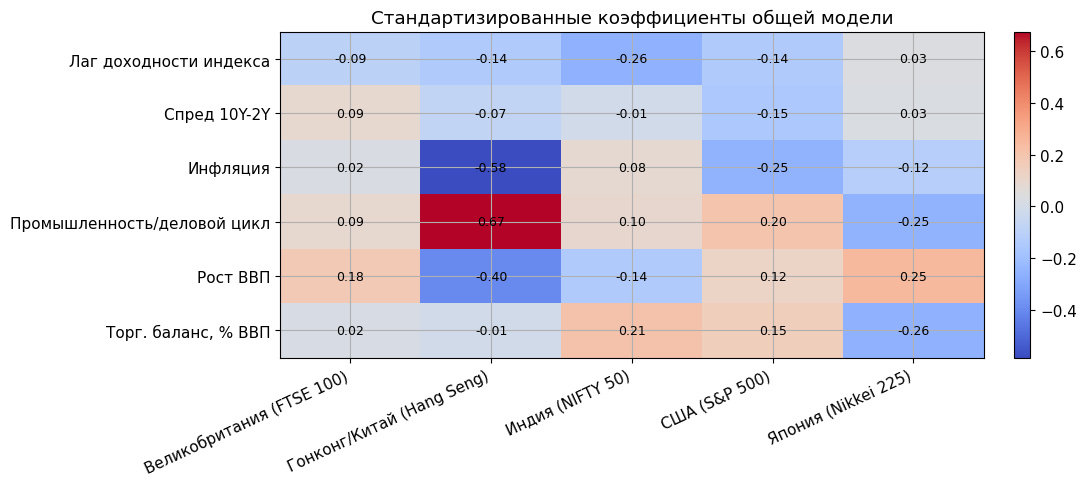

In [ ]:
heat = std_coef_table.query("variable != 'const'").pivot(
    index="variable_label", columns="country_label", values="coef"
).loc[
    [
        FACTOR_LABELS["ret_lag1"],
        FACTOR_LABELS["term_spread_lag1"],
        FACTOR_LABELS["inflation_lag1"],
        FACTOR_LABELS["industrial_proxy_lag1"],
        FACTOR_LABELS["gdp_growth_lag1"],
        FACTOR_LABELS["trade_balance_pct_gdp_lag1"],
    ]
]

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(heat.values, aspect="auto", cmap="coolwarm")

ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=25, ha="right")
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
ax.set_title("Стандартизированные коэффициенты общей модели")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "standardized_betas_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

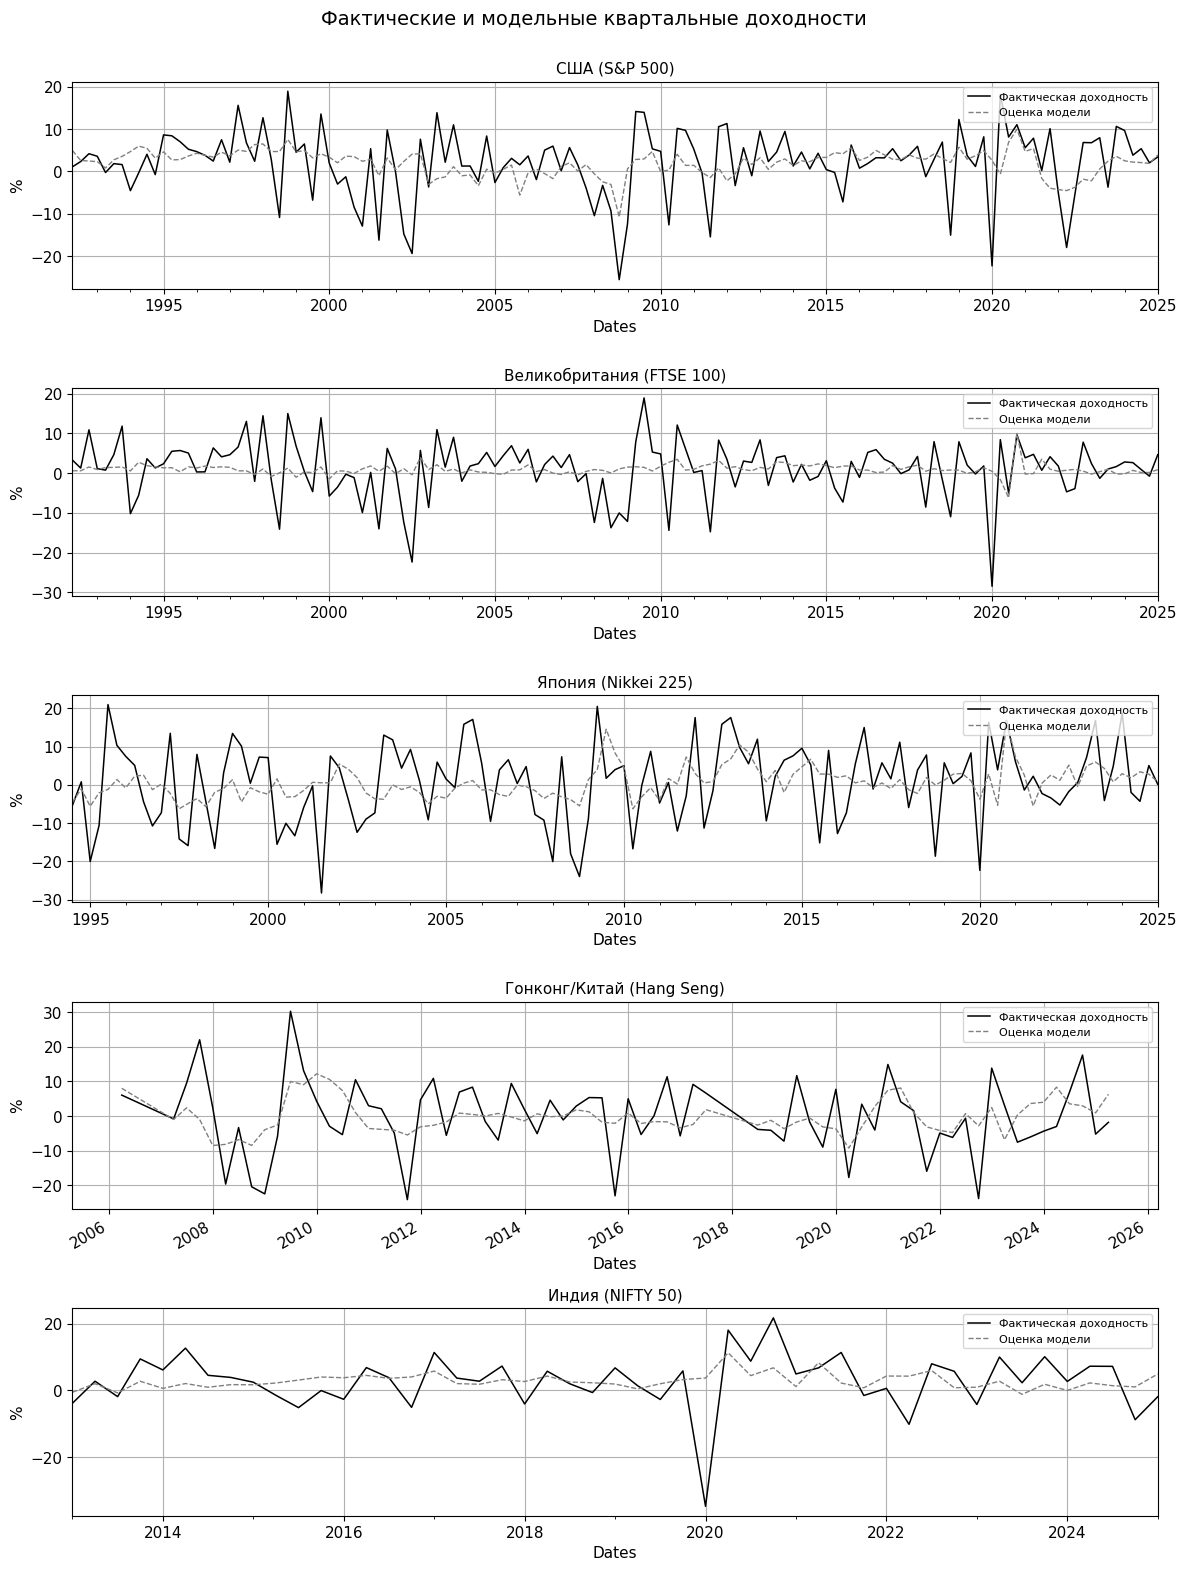

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(12, 16), sharex=False)

for ax, country in zip(axes, COUNTRY_ORDER):
    fitted_country = fitted_table.loc[fitted_table["country"] == country].copy()
    fitted_country["Dates"] = pd.to_datetime(fitted_country["Dates"])
    fitted_country = fitted_country.set_index("Dates").sort_index()

    fitted_country["actual_ret"].plot(
        ax=ax, color="black", linewidth=1.1, label="Фактическая доходность"
    )
    fitted_country["fitted_ret"].plot(
        ax=ax, color="gray", linewidth=1.0, linestyle="--", label="Оценка модели"
    )

    ax.set_title(COUNTRY_LABELS[country], fontsize=11)
    ax.set_ylabel("%")
    ax.legend(loc="upper right", fontsize=8)

fig.suptitle("Фактические и модельные квартальные доходности", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig(OUTPUT_DIR / "actual_vs_fitted.png", dpi=200, bbox_inches="tight")
plt.show()

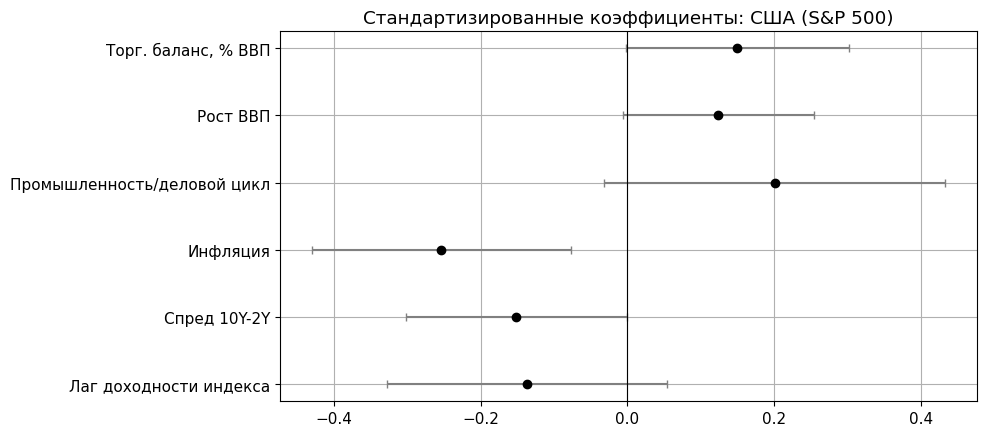

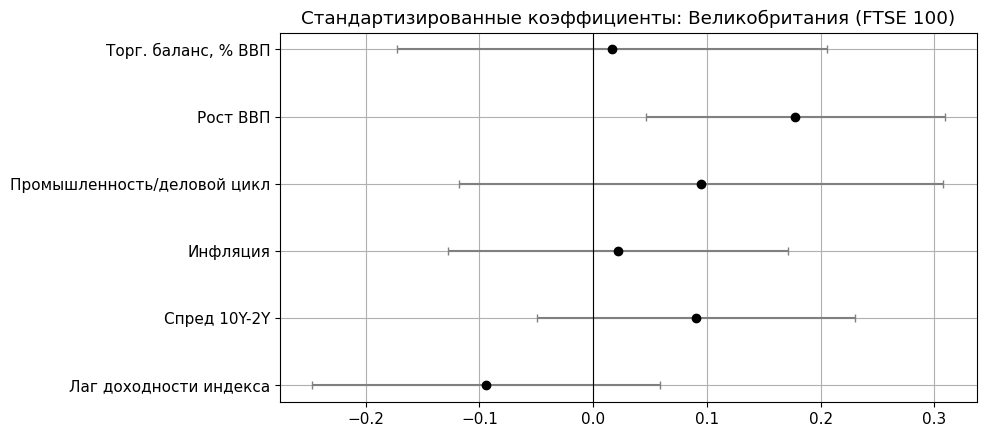

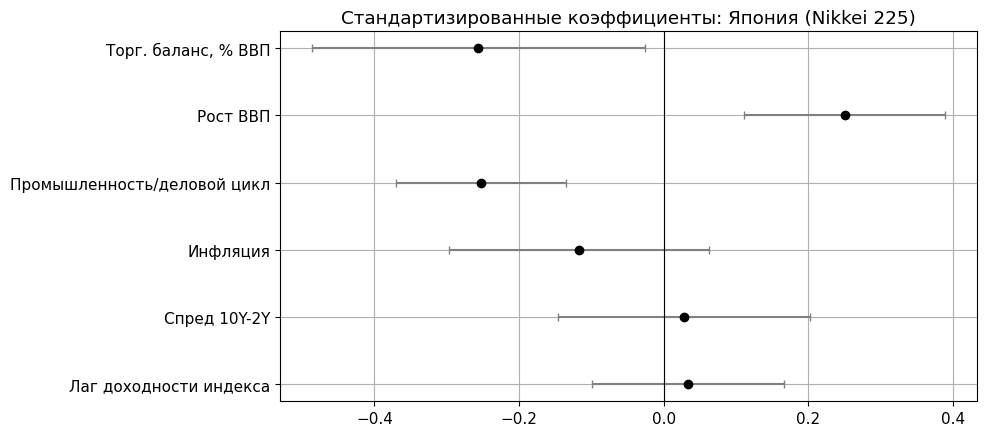

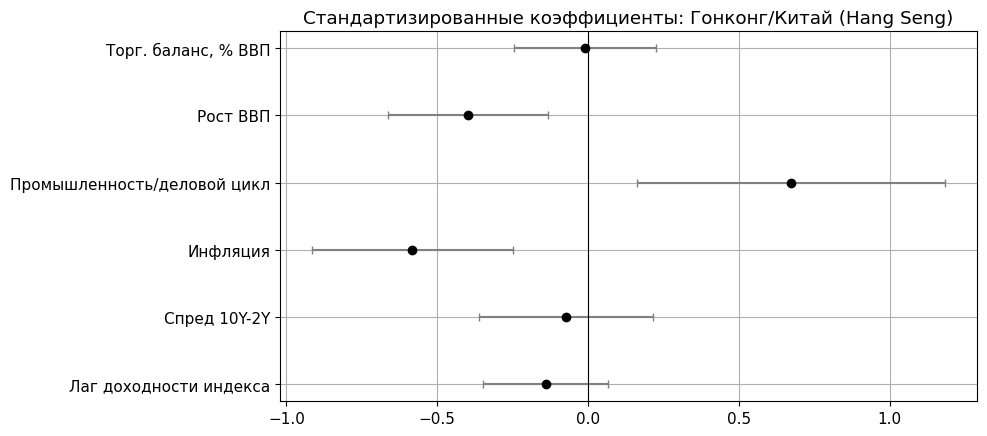

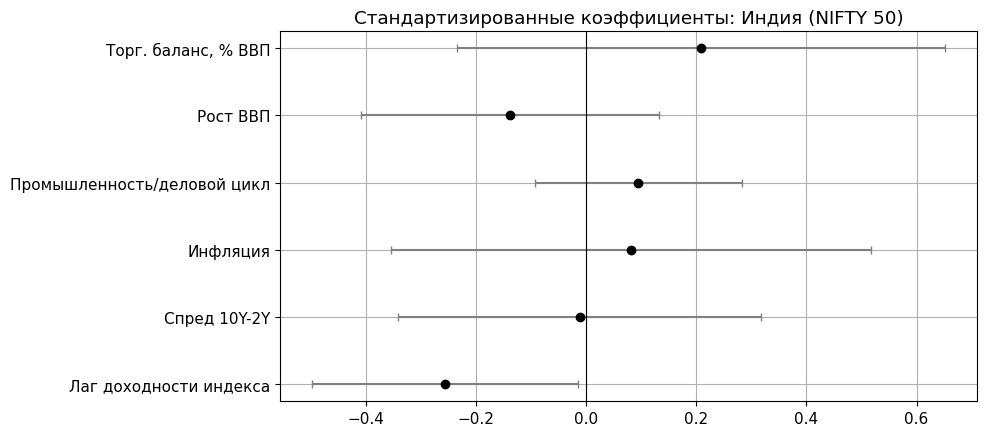

In [ ]:
for country in COUNTRY_ORDER:
    sub = std_coef_table.query("country == @country and variable != 'const'").copy()
    sub["low"] = sub["coef"] - 1.96 * sub["std_err"]
    sub["high"] = sub["coef"] + 1.96 * sub["std_err"]

    order = [
        FACTOR_LABELS["ret_lag1"],
        FACTOR_LABELS["term_spread_lag1"],
        FACTOR_LABELS["inflation_lag1"],
        FACTOR_LABELS["industrial_proxy_lag1"],
        FACTOR_LABELS["gdp_growth_lag1"],
        FACTOR_LABELS["trade_balance_pct_gdp_lag1"],
    ]
    sub = sub.set_index("variable_label").loc[order].reset_index()

    fig, ax = plt.subplots(figsize=(10, 4.5))
    y_pos = np.arange(len(sub))

    ax.errorbar(
        sub["coef"],
        y_pos,
        xerr=[sub["coef"] - sub["low"], sub["high"] - sub["coef"]],
        fmt="o",
        color="black",
        ecolor="gray",
        capsize=3,
    )
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sub["variable_label"])
    ax.set_title(f"Стандартизированные коэффициенты: {COUNTRY_LABELS[country]}")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"std_coef_{country}.png", dpi=200, bbox_inches="tight")
    plt.show()


## 8. Сохранение результатов
Эта ячейка сохраняет:
- Excel-файл со всеми основными таблицами;
- PNG-графики из ноутбука.

Файлы записываются в папку `common_macro_model_outputs`.


In [ ]:
with pd.ExcelWriter(OUTPUT_DIR / "common_macro_results.xlsx", engine="openpyxl") as writer:
    sample_summary.to_excel(writer, sheet_name="sample_summary", index=False)
    returns_adf.to_excel(writer, sheet_name="adf_returns", index=False)
    descriptive_stats.to_excel(writer, sheet_name="descriptive_stats", index=False)
    lagged_correlations.to_excel(writer, sheet_name="lagged_correlations", index=False)
    coef_table.to_excel(writer, sheet_name="ols_hac_raw", index=False)
    std_coef_table.to_excel(writer, sheet_name="ols_hac_standardized", index=False)
    diagnostics_table.to_excel(writer, sheet_name="diagnostics", index=False)
    vif_table.to_excel(writer, sheet_name="vif", index=False)
    fitted_table.to_excel(writer, sheet_name="fitted_values", index=False)

print("Сохранён Excel-файл:", OUTPUT_DIR / "common_macro_results.xlsx")
print("Список PNG-файлов:")
for file in sorted(OUTPUT_DIR.glob("*.png")):
    print(" -", file.name)

Сохранён Excel-файл: C:\Users\ggwpn\OneDrive\Desktop\Diplom\common_macro_model_outputs\common_macro_results.xlsx
Список PNG-файлов:
 - actual_vs_fitted.png
 - lagged_correlations_heatmap.png
 - quarterly_returns.png
 - standardized_betas_heatmap.png
 - std_coef_China.png
 - std_coef_India.png
 - std_coef_Japan.png
 - std_coef_UK.png
 - std_coef_US.png
